In [1]:
import pandas as pd

In [4]:
from sklearn.datasets import fetch_california_housing


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df=fetch_california_housing()

In [10]:
dataset=pd.DataFrame(df.data)

In [11]:
dataset

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [12]:
dataset.columns=df.feature_names

In [13]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [17]:
## Idependent features and dependent featurers
X=dataset
y=df.target

In [15]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [18]:
##Train test split
from sklearn.model_selection import train_test_split

# X: features, y: labels/target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [21]:
## standardizing the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [22]:
X_train=scaler.fit_transform(X_train)

In [25]:
X_test=scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LinearRegression
## cross validation 
from sklearn.model_selection import cross_val_score

In [28]:
%config Completer.use_jedi = False


In [40]:
regression=LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [34]:
mse=cross_val_score(regression, X_train,y_train, scoring='neg_mean_squared_error',cv=5)

In [35]:
np.mean(mse)

np.float64(-0.519265201143368)

In [38]:
## predicrtion
reg_pred=regression.predict(X_test)

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [41]:
reg_pred

array([-37.71038695, -37.0155379 , -36.62353773, ..., -35.81554046,
       -37.53373604, -37.03729318])

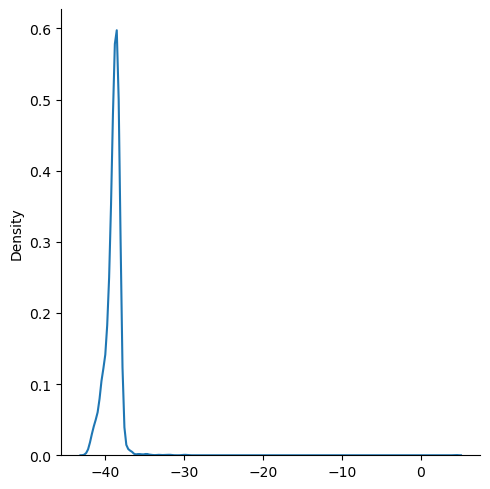

In [46]:
import seaborn as sns
sns.displot(reg_pred-y_test,kind='kde')

In [47]:
from sklearn.metrics import r2_score

In [48]:
score=r2_score(reg_pred,y_test)

In [49]:
score

-1940.4240314152175